In [1]:
# Stuff that will appear at the top of notebooks;
# You don't have to understand how this works or change it for now.

from datascience import *
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')
import warnings
warnings.simplefilter(action="ignore", category=FutureWarning)

from urllib.request import urlopen 
import re
def read_url(url): 
    return re.sub('\\s+', ' ', urlopen(url).read().decode())

# Demo for Lab 2B: Data Types and Arrays
Welcome to Lab 2B!
Our first demo and lab 02A focused on tables. We want to revisit our discussion from last week about data types to deepen our understanding of how to work with data in Python.

We're going to use the following data set from the 2014 - 2015 NBA Season (spotrac.com & basketball-reference.com) to go through some table commands. Each row represents one player.

Run the next cell to load the `player_data` table.

In [ ]:
# Just run this cell

player_data = Table.read_table('player_data.csv')

In [15]:
# Let's count the names of the characters in the chapters and create a table of counts for each chapter
# Character are 'Amy', 'Beth', 'Jo', 'Laurie', 'Meg'
counts = Table().with_columns('Amy',np.char.count(little_women_chapters, 'Amy'),
                             'Beth',np.char.count(little_women_chapters, 'Beth'),
                             'Jo', np.char.count(little_women_chapters, 'Jo'),
                             'Laurie',np.char.count(little_women_chapters, 'Laurie'),
                             'Meg', np.char.count(little_women_chapters, 'Meg'))
counts

Amy,Beth,Jo,Laurie,Meg
23,26,44,0,26
13,12,21,0,20
2,2,62,16,36
14,18,34,0,17
6,14,55,35,13
6,28,13,9,5
27,5,9,7,5
48,9,71,17,16
3,5,21,24,71
5,5,12,4,4


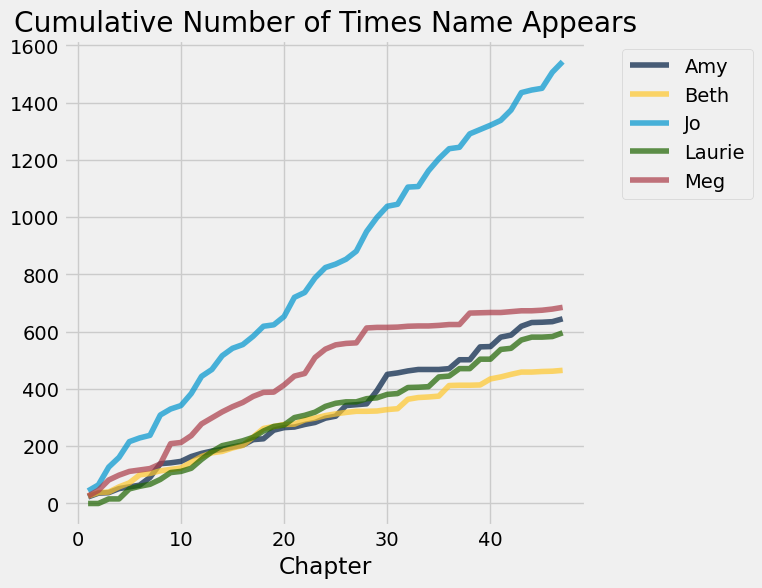

In [16]:
# Plot the cumulative counts
cum_counts = counts.cumsum().with_column('Chapter', np.arange(1, 48, 1))
cum_counts.plot(column_for_xticks=5)
plots.title('Cumulative Number of Times Name Appears');

Can we make any guesses about what happens to the characters? At some point, one of the women marries Laurie (the neighbor), can you guess who? Why?

Are you interested in another question? Maybe how many times you find the word "Christmas" or "winter" in the book? Will this give us an idea on how much time has gone by?

# Basic Python arithmatic
Let's add, divide, multiply, etc

In [17]:
value = 34 - 8


In [18]:
age = 21

age_in_decade = age + 10
age_in_decade


31

In [19]:
value * 2


52

In [20]:
34//3

11

In [21]:
34 % 3

1

In [22]:
value = -32

In [23]:
result = abs(value)
result

32

In [24]:
max(abs(-212), 43, result, 100)

212

In [25]:
huck_finn = Table().with_column("Chapter", huck_finn_chapters)
huck_finn


Chapter
I. YOU don't know about me without you have read a book ...
II. WE went tiptoeing along a path amongst the trees bac ...
"III. WELL, I got a good going-over in the morning from o ..."
"IV. WELL, three or four months run along, and it was wel ..."
V. I had shut the door to. Then I turned around and ther ...
"VI. WELL, pretty soon the old man was up and around agai ..."
"VII. ""GIT up! What you 'bout?"" I opened my eyes and look ..."
VIII. THE sun was up so high when I waked that I judged ...
IX. I wanted to go and look at a place right about the m ...
X. AFTER breakfast I wanted to talk about the dead man a ...


In [26]:
counts = Table().with_columns('Tom',np.char.count(huck_finn_chapters, 'Tom'),
                             'Jim',np.char.count(huck_finn_chapters, 'Jim'),
                             'Huck',np.char.count(huck_finn_chapters, 'Huck'))
counts

Tom,Jim,Huck
6,0,3
24,16,2
5,0,2
0,8,1
0,0,0
0,0,2
2,0,0
2,22,5
0,11,1
0,19,0


In [27]:
# TODO: Try out some of the basics, select, drop, where...
counts.select('Tom').where('Tom', are.above(5))

Tom
6
24
19
15
14
18
9
32
11
11


# Another Table Demo: How many periods in a chapter?

In [28]:
# In each chapter, count the number of all characters;
# call this the "length" of the chapter.
# Also count the number of periods.

chars_periods_hf = Table().with_columns([
        'HF Chapter Length', [len(s) for s in huck_finn_chapters],
        'Number of Periods', np.char.count(huck_finn_chapters, '.')
    ])
chars_periods_lw = Table().with_columns([
        'LW Chapter Length', [len(s) for s in little_women_chapters],
        'Number of Periods', np.char.count(little_women_chapters, '.')
    ])

In [29]:
# The counts for Huckleberry Finn

chars_periods_hf.show(3)

HF Chapter Length,Number of Periods
7026,66
11982,117
8529,72


In [30]:
# The counts for Little Women

chars_periods_lw.show(3)

LW Chapter Length,Number of Periods
21759,189
22148,188
20558,231


In [31]:
# What can we observe?

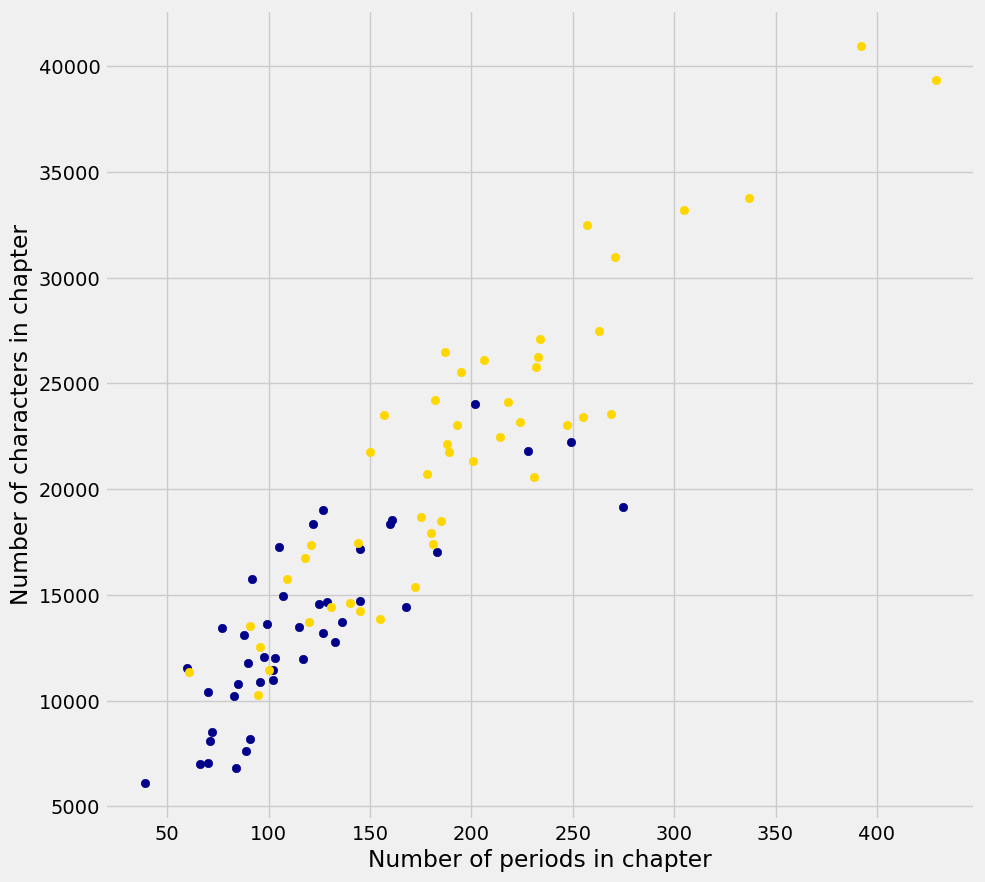

In [32]:
plots.figure(figsize=(10,10))
plots.scatter(chars_periods_hf[1], chars_periods_hf[0], color='darkblue')
plots.scatter(chars_periods_lw[1], chars_periods_lw[0], color='gold')
plots.xlabel('Number of periods in chapter')
plots.ylabel('Number of characters in chapter');

# On Average what appears to be the sentence length?

Can estimate the length of a sentence based on the number of characters and number of periods?

In [33]:
sentenceLength_hf = chars_periods_hf[0]/chars_periods_hf[1]
sentenceLength_hf


array([ 106.45454545,  102.41025641,  118.45833333,   80.94047619,
         89.73626374,  116.4       ,  104.07874016,   89.18875502,
        113.81690141,  100.51428571,   85.93452381,  113.68217054,
        123.30120482,   85.61797753,  122.91836735,   93.04371585,
        118.49655172,  118.96534653,  164.37142857,  150.31147541,
         69.71636364,  149.01428571,  112.17647059,  116.90291262,
        139.91588785,  101.49655172,  137.45454545,  114.66875   ,
        149.90551181,  156.8974359 ,  115.04968944,  130.74444444,
        117.09565217,  107.52941176,  100.82352941,  126.96470588,
        148.80681818,   96.07518797,  113.16666667,  192.23333333,
        174.41558442,  171.23913043,   95.60526316])

In [34]:
sentenceLength_lw = chars_periods_lw[0]/chars_periods_lw[1]
sentenceLength_lw

array([ 115.12698413,  117.80851064,   88.995671  ,  130.9025641 ,
         91.74509804,  104.44285714,  110.16030534,  105.02803738,
        100.19881306,  100.04324324,  119.29533679,   91.75524476,
        106.68      ,   99.57777778,   96.04972376,   89.26162791,
         89.54193548,  121.05555556,  143.2892562 ,   98.28965517,
         87.52788104,  114.23333333,   93.17813765,  133.18131868,
        148.63736264,  144.92666667,  144.53211009,  114.36162362,
        112.67811159,  110.72018349,  116.42134831,  103.38392857,
        111.10775862,  126.44357977,  106.0199005 ,  114.41      ,
        149.8343949 ,  126.65533981,  104.46007605,  186.36065574,
        141.51871658,  141.97457627,  108.85901639,  108.30526316,
        130.8125    ,  115.78632479,  104.42602041])

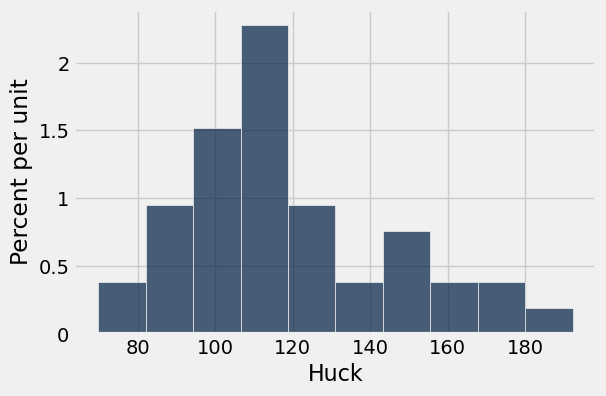

In [35]:
Table().with_columns('Huck', sentenceLength_hf).hist()

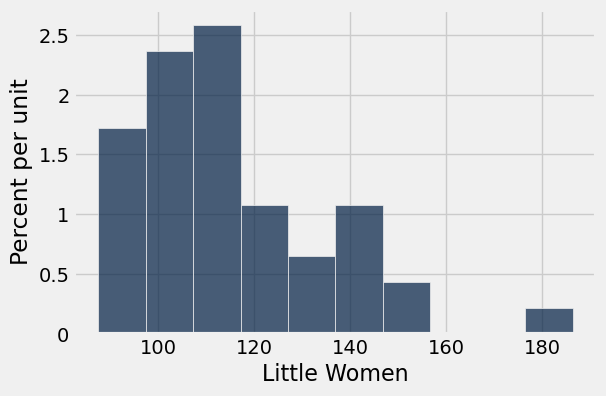

In [36]:
# How long are sentences on average?
#TODO: Try this now with the "Little Women". Is the histogram similar/different?

Table().with_columns('Little Women', sentenceLength_lw).hist()

Interestingly: on Twitter: max length of tweet was 140 until 2017, and only recently became longer. Today it is 280. Check out this interesting study on how character limits affected language useage: https://www.nature.com/articles/s41599-019-0280-3

### Another example: Reading in a Table from a comma seperated value (.csv) file

The table `California_airquality.csv` contains data on air quality in California 1/1/2020 through 9/10/2020 of the air quality index in California as measured by PM2.5, the main pollutant from fire (data is from 2 sources: AQS, AirNow). I found the dataset on Kaggle, direct link here:https://www.kaggle.com/thaddeussegura/california-air-quality-2020-through-sept10th. Kaggle is an open source/free platform where anyone interested in data science can share code and data sets (https://www.kaggle.com/datasets).

In [37]:
CalAQI = Table.read_table('California_airquality.csv')
CalAQI
#TODO: narrow down table to only selecting what we want to look at
# For example: Date, Site Name, DAILY_AQI_VALUE
onlyAQI = CalAQI.select('Date', 'Site Name', 'DAILY_AQI_VALUE')
onlyAQI

Date,Site Name,DAILY_AQI_VALUE
1/1/20,Livermore,36
1/2/20,Livermore,19
1/3/20,Livermore,55
1/4/20,Livermore,45
1/5/20,Livermore,33
1/6/20,Livermore,26
1/7/20,Livermore,29
1/8/20,Livermore,13
1/9/20,Livermore,25
1/10/20,Livermore,23


### Table operations
Selecting specific columns;
Sorting the data;
Finding where a specific value in a column is set to value of interest:
for example, let's see if we can find Site Name = SB

In [38]:
# look for when Santa Barbara had high AQI during this time
onlyAQI.where('Site Name', 'Santa Barbara').where('DAILY_AQI_VALUE', are.above(100))


Date,Site Name,DAILY_AQI_VALUE
8/20/20,Santa Barbara,112
8/21/20,Santa Barbara,125
